In [41]:
'''
!pip install qiskit-aer


#Solver for classical computing
!sudo apt-get install coinor-cbc
!glpsol --version
'''

'\n!pip install qiskit-aer\n\n\n#Solver for classical computing\n!sudo apt-get install coinor-cbc\n!glpsol --version\n'

In [42]:
# qaoa_portfolio_optimization.py

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit_aer import Aer
from scipy.optimize import minimize
import seaborn as sns

# -----------------------------
# Financial data
# -----------------------------
n_assets = 4
np.random.seed(42)

mu = np.random.uniform(0.05, 0.2, n_assets)

F = np.random.normal(0, 0.05, (n_assets, 2))
specific = np.diag(np.random.uniform(0.01, 0.03, n_assets))
cov = F @ F.T + specific

lambda_risk = 0.5

print("Expected Returns", mu)

Expected Returns [0.10618102 0.19260715 0.15979909 0.13979877]



Asset Statistics:
        Expected Return (%)  Std Dev (%)
Asset1                10.62        12.79
Asset2                19.26        16.79
Asset3                15.98        14.12
Asset4                13.98        13.00


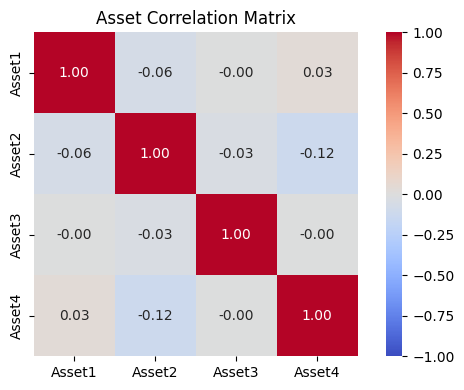

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Convert returns to %
# -----------------------------
returns_pct = mu * 100

# Standard deviation (from covariance diagonal)
std_dev = np.sqrt(np.diag(cov)) * 100

# Create a dataframe for readability
asset_labels = [f"Asset{i+1}" for i in range(n_assets)]

financial_df = pd.DataFrame({
    "Expected Return (%)": returns_pct,
    "Std Dev (%)": std_dev
}, index=asset_labels)

print("\nAsset Statistics:")
print(financial_df.round(2))


# -----------------------------
# Correlation matrix
# -----------------------------
# Convert covariance to correlation matrix
# standard deviations (NOT variances)
std = np.sqrt(np.diag(cov))

# correct denominator: sigma_i * sigma_j
std_matrix = np.outer(std, std)
corr_matrix = cov / std_matrix

corr_df = pd.DataFrame(corr_matrix, index=asset_labels, columns=asset_labels)

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Asset Correlation Matrix")
plt.tight_layout()
plt.show()

In [44]:


# -----------------------------
# QAOA Circuit
# -----------------------------

def apply_cost_unitary(qc, gamma, mu, cov):
    n = len(mu)
    for i in range(n):
        qc.rz(2 * gamma * mu[i], i)
    for i in range(n):
        for j in range(i + 1, n):
            qc.cx(i, j)
            qc.rz(2 * gamma * cov[i][j], j)
            qc.cx(i, j)

def apply_mixer(qc, beta, n):
    for i in range(n):
        qc.rx(2 * beta, i)

def create_qaoa_circuit(n, mu, cov, p):
    qc = QuantumCircuit(n)
    gammas = [Parameter(f'gamma_{i}') for i in range(p)]
    betas = [Parameter(f'beta_{i}') for i in range(p)]

    for i in range(n):
        qc.h(i)

    for layer in range(p):
        apply_cost_unitary(qc, gammas[layer], mu, cov)
        apply_mixer(qc, betas[layer], n)

    qc.measure_all()
    return qc, gammas, betas

# -----------------------------
# Objective function
# -----------------------------

backend = Aer.get_backend("aer_simulator")

def objective(params, qc, gammas, betas, mu, cov, lambda_risk):
    param_dict = {}

    for i in range(len(gammas)):
        param_dict[gammas[i]] = params[i]
        param_dict[betas[i]] = params[i + len(gammas)]

    bound_qc = qc.assign_parameters(param_dict)
    compiled = transpile(bound_qc, backend)

    job = backend.run(compiled, shots=1024)
    result = job.result()
    counts = result.get_counts()

    exp_value = 0

    for bitstring, count in counts.items():
        prob = count / 1024
        bitstring = bitstring[::-1]

        x = np.array([int(b) for b in bitstring])

        return_term = np.dot(mu, x)
        risk_term = x @ cov @ x

        cost = return_term - lambda_risk * risk_term
        exp_value += prob * cost

    return -exp_value

# -----------------------------
# Run QAOA
# -----------------------------

p = 1
qc, gammas, betas = create_qaoa_circuit(n_assets, mu, cov, p)

init_params = np.random.rand(2 * p)

res = minimize(
    objective,
    init_params,
    args=(qc, gammas, betas, mu, cov, lambda_risk),
    method='COBYLA'
)

print("QAOA Optimal parameters:", res.x)

# Extract best solution
best_params = res.x
param_dict = {gammas[0]: best_params[0], betas[0]: best_params[1]}

bound_qc = qc.assign_parameters(param_dict)
compiled = transpile(bound_qc, backend)
result = backend.run(compiled, shots=2048).result()
counts = result.get_counts()

sorted_portfolios = sorted(counts.items(), key=lambda x: -x[1])

print("\nTop QAOA portfolios:")
for bitstring, count in sorted_portfolios[:5]:
    bitstring = bitstring[::-1]
    x = np.array([int(b) for b in bitstring])

    ret = np.dot(mu, x)
    risk = x @ cov @ x
    val = ret - lambda_risk * risk

    print(f"{bitstring} | prob={count/2048:.3f} | value={val:.4f}")

# -----------------------------
# Classical optimization (Pyomo)
# -----------------------------
"""
try:
    from pyomo.environ import *

    model = ConcreteModel()
    model.x = Var(range(n_assets), domain=Binary)

    def obj_rule(model):
        return sum(mu[i] * model.x[i] for i in range(n_assets)) -                lambda_risk * sum(cov[i][j] * model.x[i] * model.x[j]
                                 for i in range(n_assets)
                                 for j in range(n_assets))

    model.obj = Objective(rule=obj_rule, sense=maximize)

    solver = SolverFactory('cbc')
    solver.solve(model)

    x_classical = np.array([int(model.x[i].value) for i in range(n_assets)])

    ret_classical = np.dot(mu, x_classical)
    risk_classical = x_classical @ cov @ x_classical
    val_classical = ret_classical - lambda_risk * risk_classical

    print("\nClassical optimal portfolio:")
    print("x =", x_classical)
    print("Return =", ret_classical)
    print("Risk =", risk_classical)
    print("Objective =", val_classical)

except Exception as e:
    print("\nPyomo not available or solver missing:", e)
  """

import itertools
import numpy as np

def classical_exact(mu, cov, lambda_risk):
    n = len(mu)
    best_x = None
    best_val = -1e9

    for bits in itertools.product([0, 1], repeat=n):
        x = np.array(bits)

        ret = mu @ x
        risk = x @ cov @ x
        val = ret - lambda_risk * risk

        if val > best_val:
            best_val = val
            best_x = x

    return best_x, best_val

x_classical, val_classical = classical_exact(mu, cov, lambda_risk)

print("Classical exact solution:", x_classical)
print("Value:", val_classical)



QAOA Optimal parameters: [ 2.90005321 -0.79298966]

Top QAOA portfolios:
1111 | prob=0.572 | value=0.5622
0111 | prob=0.159 | value=0.4633
1110 | prob=0.094 | value=0.4286
1101 | prob=0.066 | value=0.4114
1011 | prob=0.027 | value=0.3788
Classical exact solution: [1 1 1 1]
Value: 0.5621866266222438


In [45]:
# Post-processing Step 1: Convert counts → probability distribution


counts = result.get_counts()
import matplotlib.pyplot as plt

# Convert counts to probabilities
total_shots = sum(counts.values())
final_distribution_bin = {
    k[::-1]: v / total_shots for k, v in counts.items()
}

In [46]:

#Post-processing Step 2: Get most likely portfolio
def bitstring_to_array(bitstring):
    return np.array([int(b) for b in bitstring])

keys = list(final_distribution_bin.keys())
values = list(final_distribution_bin.values())

most_likely = keys[np.argmax(values)]
most_likely_array = bitstring_to_array(most_likely)

print("Most likely portfolio:", most_likely_array)

Most likely portfolio: [1 1 1 1]


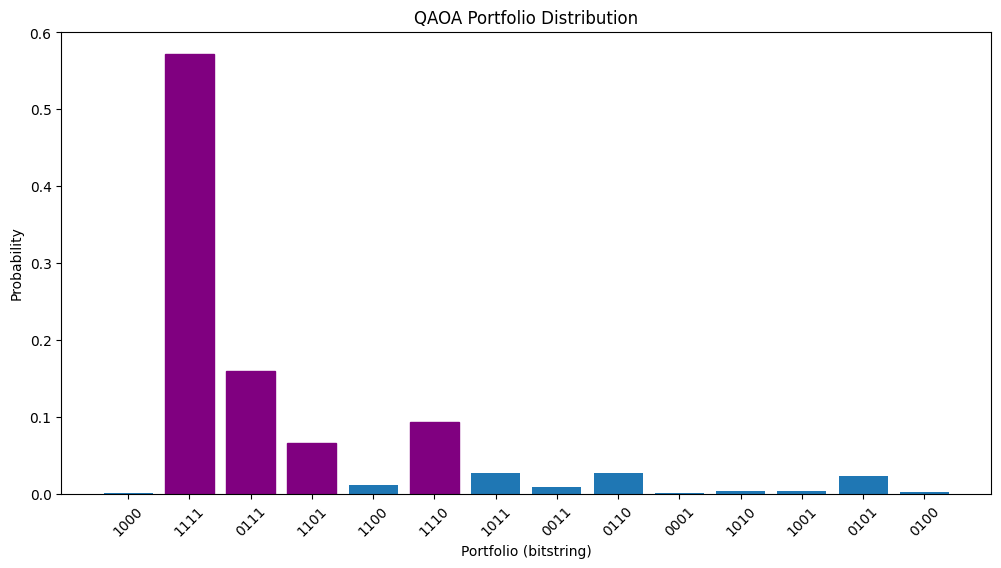

In [47]:
# Post-processing Step 3: Plot probability distribution

plt.figure(figsize=(12, 6))

bitstrings = list(final_distribution_bin.keys())
probs = list(final_distribution_bin.values())

bars = plt.bar(bitstrings, probs)

# Highlight top 4 portfolios
top_k = 4
top_indices = np.argsort(probs)[-top_k:]

for idx in top_indices:
    bars[idx].set_color("purple")

plt.xticks(rotation=45)
plt.xlabel("Portfolio (bitstring)")
plt.ylabel("Probability")
plt.title("QAOA Portfolio Distribution")

plt.show()

In [48]:
# Post-processing Step 4: Visualize portfolio characteristics (IMPORTANT for finance)

def portfolio_metrics(x, mu, cov, lambda_risk):
    ret = np.dot(mu, x)
    risk = x @ cov @ x
    value = ret - lambda_risk * risk
    return ret, risk, value

# Evaluate top portfolios
top_portfolios = sorted(
    final_distribution_bin.items(),
    key=lambda x: -x[1]
)[:5]

returns = []
risks = []
labels = []

for bitstring, prob in top_portfolios:
    x = bitstring_to_array(bitstring)
    ret, risk, val = portfolio_metrics(x, mu, cov, lambda_risk)

    returns.append(ret)
    risks.append(risk)
    labels.append(bitstring)

    print(f"{bitstring} | prob={prob:.3f} | return={ret:.4f} | risk={risk:.4f}")

1111 | prob=0.572 | return=0.5984 | risk=0.0724
0111 | prob=0.159 | return=0.4922 | risk=0.0578
1110 | prob=0.094 | return=0.4586 | risk=0.0600
1101 | prob=0.066 | return=0.4386 | risk=0.0544
1011 | prob=0.027 | return=0.4058 | risk=0.0540


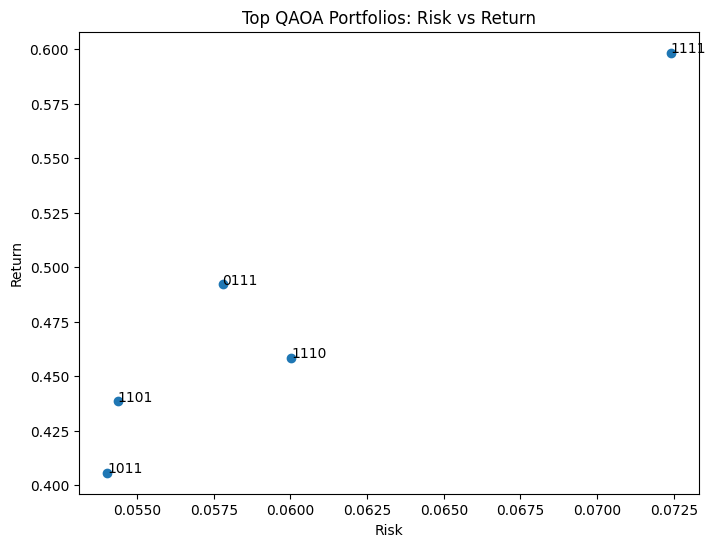

In [49]:
# Post-processing Step 5: Plot Risk vs Return (this is your “quant insight” plot)

plt.figure(figsize=(8, 6))

plt.scatter(risks, returns)

for i, label in enumerate(labels):
    plt.annotate(label, (risks[i], returns[i]))

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Top QAOA Portfolios: Risk vs Return")

plt.show()

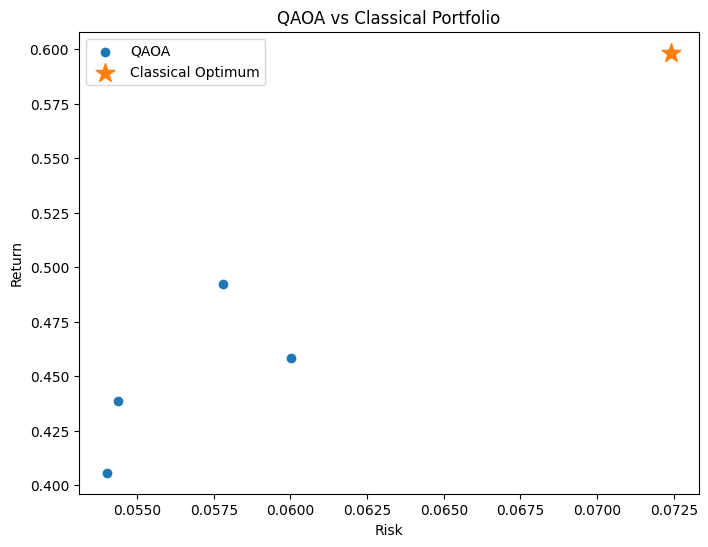

In [50]:
# Post-processing Optional (Highly Recommended): Compare with classical solution

ret_c, risk_c, _ = portfolio_metrics(x_classical, mu, cov, lambda_risk)

plt.figure(figsize=(8, 6))

# QAOA portfolios
plt.scatter(risks, returns, label="QAOA")

# Classical optimum
plt.scatter([risk_c], [ret_c], marker="*", s=200, label="Classical Optimum")

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("QAOA vs Classical Portfolio")

plt.legend()
plt.show()